# Notebook testing a function to get tile id from object coordinate

Notebook that aims at testing a function that gets the tile ID of an object based on its coordinates 

In [63]:
# hack the paths, no package install needed
import sys
import os
repo_dir = '/media/user/repos_2/bulk-euclid-cutouts'
os.path.isdir(repo_dir)
sys.path.insert(0,repo_dir)
# Access astronomical databases
# from pyvo import registry  # version >=1.4.1 
import logging
logging.basicConfig(level=logging.INFO)
import os

import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
#from omegaconf import OmegaConf
import pandas as pd
from astropy.table import Table
import healpy
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.coordinates import SkyCoord, ICRS,match_coordinates_sky
import astropy.coordinates as coord
from matplotlib.colors import LogNorm
#from bulk_euclid.external_targets import pipeline
# import bulk_euclid
# from bulk_euclid.utils import morphology_utils_ou_mer, cutout_utils, pipeline_utils

In [4]:
# file with tile ids based on healpix ID https://euclid.roe.ac.uk/projects/mer_pf/wiki/Tiling#Healpix-maps-for-Wide-Field-V12-tiling 
hp_V1_2 = healpy.read_map('tile_index_map.v1.2.fits.gz', nest=True)

INFO:healpy:NSIDE = 8192
INFO:healpy:ORDERING = NESTED in fits file
INFO:healpy:INDXSCHM = IMPLICIT


In [5]:
# Test of getting tile id based on coordinates (of some Q1 objects) -
# Based on https://gitlab.euclid-sgs.uk/PF-MER/MER_DA/-/blob/develop/MER_DA/python/MER_DA/MER_HPObjectSelection.py?ref_type=heads#L170
ra, dec = 59.56467277951752, -50.94691775377698
hp_theta = np.pi/2. - dec/180.*np.pi
hp_phi   = ra/180.*np.pi
#moc_order = np.arange(10,13)    # /!\ HARD-CODED BY DS BUT there is a setup in MER code It should depend on the Healpix.fits file used ... ?! 
moc_order = 13
hp_object_indices = healpy.pixelfunc.ang2pix(healpy.order2nside(moc_order), hp_theta, hp_phi, nest=True)
true_tile = 102018668045581 // 1000000
tile_index = hp_V1_2[hp_object_indices]
hp_object_indices, tile_index, true_tile

(562148276, 102018668, 102018668)

In [6]:
hp_V1_2[hp_object_indices]

102018668

In [7]:
# Another one
ra, dec = 271.6319161478719, 66.85423311849298
hp_theta = np.pi/2. - dec/180.*np.pi
hp_phi   = ra/180.*np.pi
#moc_order = np.arange(10,14)    # /!\ HARD-CODED BY DS BUT there is a setup in MER code It should depend on the Healpix.fits file used ... ?! 
moc_order = 13
hp_object_indices = healpy.pixelfunc.ang2pix(healpy.order2nside(moc_order), hp_theta, hp_phi, nest=True)
true_tile = 102159777024473 // 1000000
hp_V1_2[hp_object_indices], true_tile
#hp_object_indices / true_tile, hp_object_indices, true_tile

(102159777, 102159777)

In [8]:
hp_object_indices

262851199

## Now a function and some more systematic testing 

In [9]:
import math 

In [10]:
def get_matching_tile_indices(ra, dec, healpix_array):
    """
    Prototype function from DS to get tile index for a given coord based on an healpix_file
    based on https://gitlab.euclid-sgs.uk/PF-MER/MER_DA/-/blob/develop/MER_DA/python/MER_DA/MER_HPObjectSelection.py?ref_type=heads#L170
    Tile info. based on healpix: -tiling v1.2 -
    https://euclid.roe.ac.uk/projects/mer_pf/wiki/Tiling#Healpix-maps-for-Wide-Field-V12-tiling
    Healpix file 1.2 available on the redmine
    Args:
        ra: np.array of ra in deg (likely output of target['target_ra'].values (for one specific target))
        dec: np.array dec in deg (likely output of target['target_deg'].values (for one specific target))
        healpix_array: np.array w. healpix indices = output of `healpy.read_map('tile_index_map.v1.2.fits.gz', nest=True)`

    Returns: np.array - tile indices

    """
    # convert Ra/Dec from [dec] to [rad]
    # !MER uses math.pi instead np.pi
    #hp_theta = np.pi/2. - dec/180.*np.pi
    hp_theta = math.pi/2. - dec/180.*math.pi
    hp_phi   = ra/180.*math.pi

    # get the healpix indices for all objects
    moc_order = 13    # /!\ HARD-CODED BUT there is a setup in MER code; Should remain 13 forever according to M.Kuemmel
    hp_object_indices = healpy.pixelfunc.ang2pix(healpy.order2nside(moc_order), hp_theta, hp_phi, nest=True)

    tile_index = healpix_array[hp_object_indices]
    return tile_index

In [11]:
ra_arr = np.array([59.56467277951752, 271.6319161478719])
dec_arr = np.array([-50.94691775377698, 66.85423311849298] )
expeced_tiles = np.array([102018668, 102159777])
get_matching_tile_indices(ra_arr, dec_arr, hp_V1_2)

array([102018668, 102159777], dtype=int32)

In [12]:
euclid_phot_lenses = Table.read('euclid_mer_photometry_lenses.fits')
t_id = get_matching_tile_indices(euclid_phot_lenses['right_ascension'], euclid_phot_lenses['declination'], hp_V1_2)
true_t_id = euclid_phot_lenses['segmentation_map_id'] // 1000000
true_t_id2 = np.asarray((euclid_phot_lenses['segmentation_map_id'] / 1000000), dtype=int)

In [13]:
len(euclid_phot_lenses)

2415

In [14]:
np.sum(true_t_id - t_id), np.sum(true_t_id2 - t_id)

(1090, 1090)

In [15]:
non_zeros = np.where((true_t_id - t_id) != 0 ) 
non_zeros

(array([   8,  759, 1342, 2338]),)

In [16]:
t_id[non_zeros], true_t_id[non_zeros]

(array([102158590, 102157953, 102020062, 102042918], dtype=int32),
 <Column name='segmentation_map_id' dtype='int64' length=4>
 102158896
 102157630
 102020535
 102043552)

Possibles reasons for those mismatch tiles: 
- accuracy in pi -> use of math.pi instead of np.pi: no effect 
- ra-dec rounding accuracy? 
- segmentation area too large => objects covers more of a new tile ... 
- object close to the edge of the tile 
- Some objects are special objects? / part of the special objects catalog - https://euclid.roe.ac.uk/projects/mer_pf/wiki/Tiling#Healpix-maps-for-Wide-Field-V12-tiling 

In [17]:
euclid_phot_lenses[non_zeros]

basic_download_data_oid,to_be_published,object_id,right_ascension,declination,right_ascension_psf_fitting,declination_psf_fitting,segmentation_map_id,vis_det,flux_vis_1fwhm_aper,flux_vis_2fwhm_aper,flux_vis_3fwhm_aper,flux_vis_4fwhm_aper,flux_y_1fwhm_aper,flux_y_2fwhm_aper,flux_y_3fwhm_aper,flux_y_4fwhm_aper,flux_j_1fwhm_aper,flux_j_2fwhm_aper,flux_j_3fwhm_aper,flux_j_4fwhm_aper,flux_h_1fwhm_aper,flux_h_2fwhm_aper,flux_h_3fwhm_aper,flux_h_4fwhm_aper,flux_nir_stack_1fwhm_aper,flux_nir_stack_2fwhm_aper,flux_nir_stack_3fwhm_aper,flux_nir_stack_4fwhm_aper,flux_u_ext_decam_1fwhm_aper,flux_u_ext_decam_2fwhm_aper,flux_u_ext_decam_3fwhm_aper,flux_u_ext_decam_4fwhm_aper,flux_g_ext_decam_1fwhm_aper,flux_g_ext_decam_2fwhm_aper,flux_g_ext_decam_3fwhm_aper,flux_g_ext_decam_4fwhm_aper,flux_r_ext_decam_1fwhm_aper,flux_r_ext_decam_2fwhm_aper,flux_r_ext_decam_3fwhm_aper,flux_r_ext_decam_4fwhm_aper,flux_i_ext_decam_1fwhm_aper,flux_i_ext_decam_2fwhm_aper,flux_i_ext_decam_3fwhm_aper,flux_i_ext_decam_4fwhm_aper,flux_z_ext_decam_1fwhm_aper,flux_z_ext_decam_2fwhm_aper,flux_z_ext_decam_3fwhm_aper,flux_z_ext_decam_4fwhm_aper,flux_u_ext_lsst_1fwhm_aper,flux_u_ext_lsst_2fwhm_aper,flux_u_ext_lsst_3fwhm_aper,flux_u_ext_lsst_4fwhm_aper,flux_g_ext_lsst_1fwhm_aper,flux_g_ext_lsst_2fwhm_aper,flux_g_ext_lsst_3fwhm_aper,flux_g_ext_lsst_4fwhm_aper,flux_r_ext_lsst_1fwhm_aper,flux_r_ext_lsst_2fwhm_aper,flux_r_ext_lsst_3fwhm_aper,flux_r_ext_lsst_4fwhm_aper,flux_i_ext_lsst_1fwhm_aper,flux_i_ext_lsst_2fwhm_aper,flux_i_ext_lsst_3fwhm_aper,flux_i_ext_lsst_4fwhm_aper,flux_z_ext_lsst_1fwhm_aper,flux_z_ext_lsst_2fwhm_aper,flux_z_ext_lsst_3fwhm_aper,flux_z_ext_lsst_4fwhm_aper,flux_u_ext_megacam_1fwhm_aper,flux_u_ext_megacam_2fwhm_aper,flux_u_ext_megacam_3fwhm_aper,flux_u_ext_megacam_4fwhm_aper,flux_r_ext_megacam_1fwhm_aper,flux_r_ext_megacam_2fwhm_aper,flux_r_ext_megacam_3fwhm_aper,flux_r_ext_megacam_4fwhm_aper,flux_g_ext_jpcam_1fwhm_aper,flux_g_ext_jpcam_2fwhm_aper,flux_g_ext_jpcam_3fwhm_aper,flux_g_ext_jpcam_4fwhm_aper,flux_i_ext_panstarrs_1fwhm_aper,flux_i_ext_panstarrs_2fwhm_aper,flux_i_ext_panstarrs_3fwhm_aper,flux_i_ext_panstarrs_4fwhm_aper,flux_z_ext_panstarrs_1fwhm_aper,flux_z_ext_panstarrs_2fwhm_aper,flux_z_ext_panstarrs_3fwhm_aper,flux_z_ext_panstarrs_4fwhm_aper,flux_g_ext_hsc_1fwhm_aper,flux_g_ext_hsc_2fwhm_aper,flux_g_ext_hsc_3fwhm_aper,flux_g_ext_hsc_4fwhm_aper,flux_z_ext_hsc_1fwhm_aper,flux_z_ext_hsc_2fwhm_aper,flux_z_ext_hsc_3fwhm_aper,flux_z_ext_hsc_4fwhm_aper,fluxerr_vis_1fwhm_aper,fluxerr_vis_2fwhm_aper,fluxerr_vis_3fwhm_aper,fluxerr_vis_4fwhm_aper,fluxerr_y_1fwhm_aper,fluxerr_y_2fwhm_aper,fluxerr_y_3fwhm_aper,fluxerr_y_4fwhm_aper,fluxerr_j_1fwhm_aper,fluxerr_j_2fwhm_aper,fluxerr_j_3fwhm_aper,fluxerr_j_4fwhm_aper,fluxerr_h_1fwhm_aper,fluxerr_h_2fwhm_aper,fluxerr_h_3fwhm_aper,fluxerr_h_4fwhm_aper,fluxerr_nir_stack_1fwhm_aper,fluxerr_nir_stack_2fwhm_aper,fluxerr_nir_stack_3fwhm_aper,fluxerr_nir_stack_4fwhm_aper,fluxerr_u_ext_decam_1fwhm_aper,fluxerr_u_ext_decam_2fwhm_aper,fluxerr_u_ext_decam_3fwhm_aper,fluxerr_u_ext_decam_4fwhm_aper,fluxerr_g_ext_decam_1fwhm_aper,fluxerr_g_ext_decam_2fwhm_aper,fluxerr_g_ext_decam_3fwhm_aper,fluxerr_g_ext_decam_4fwhm_aper,fluxerr_r_ext_decam_1fwhm_aper,fluxerr_r_ext_decam_2fwhm_aper,fluxerr_r_ext_decam_3fwhm_aper,fluxerr_r_ext_decam_4fwhm_aper,fluxerr_i_ext_decam_1fwhm_aper,fluxerr_i_ext_decam_2fwhm_aper,fluxerr_i_ext_decam_3fwhm_aper,fluxerr_i_ext_decam_4fwhm_aper,fluxerr_z_ext_decam_1fwhm_aper,fluxerr_z_ext_decam_2fwhm_aper,fluxerr_z_ext_decam_3fwhm_aper,fluxerr_z_ext_decam_4fwhm_aper,fluxerr_u_ext_lsst_1fwhm_aper,fluxerr_u_ext_lsst_2fwhm_aper,fluxerr_u_ext_lsst_3fwhm_aper,fluxerr_u_ext_lsst_4fwhm_aper,fluxerr_g_ext_lsst_1fwhm_aper,fluxerr_g_ext_lsst_2fwhm_aper,fluxerr_g_ext_lsst_3fwhm_aper,fluxerr_g_ext_lsst_4fwhm_aper,fluxerr_r_ext_lsst_1fwhm_aper,fluxerr_r_ext_lsst_2fwhm_aper,fluxerr_r_ext_lsst_3fwhm_aper,fluxerr_r_ext_lsst_4fwhm_aper,fluxerr_i_ext_lsst_1fwhm_aper,fluxerr_i_ext_lsst_2fwhm_aper,fluxerr_i_ext_lsst_3fwhm_a

In [18]:
euclid_phot_lenses['segmentation_area'].min(), euclid_phot_lenses['segmentation_area'].max()

(205, 710965)

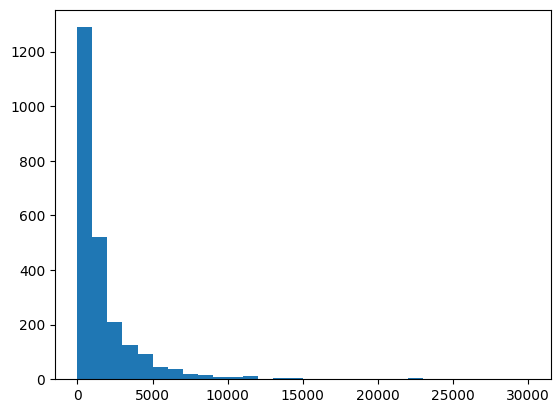

In [19]:
plt.hist(euclid_phot_lenses['segmentation_area'], range=[0, 30000], bins=30); 

In [20]:
# Special objects catalog
Special_objects = Table.read('FINAL_catalog_tiling_2023-09-15_special_objects.fits')
Special_objects[0:3]

object,RA_CEN,DEC_CEN,WIDTH,HEIGHT
bytes31,float64,float64,float64,float64
G_PGC1985872,0.0023339999999999997,32.2091944,2.421446939998476,2.421446939998476
G_PGC130936,0.0035924999999999998,-40.9032806,3.404224647629256,3.404224647629256
G_UGC12889,0.006945,47.2745815,7.158086721317912,7.158086721317912


In [21]:
ra_bad, dec_bad = euclid_phot_lenses[non_zeros]['right_ascension'], euclid_phot_lenses[non_zeros]['declination'], 
ra_bad, dec_bad

(<Column name='right_ascension' dtype='float64' length=4>
 275.26450367571215
  266.9254960967968
 61.406423912397884
  54.89862971232618,
 <Column name='declination' dtype='float64' length=4>
   65.23749986490333
   63.75113237739114
  -49.24993172823451
 -28.749401253332696)

In [22]:
np.sum(true_t_id[non_zeros] - t_id[non_zeros])

1090

In [23]:
ref_tile_bad = true_t_id[non_zeros]
for dec_rnd in range(0, 6):
    t_id_test = get_matching_tile_indices(ra_bad.round(decimals=dec_rnd), dec_bad.round(decimals=dec_rnd), hp_V1_2)
#    print(ref_tile_bad, t_id_test)
    print(dec_rnd, np.sum(ref_tile_bad-t_id_test))

0 616
1 -17
2 1413
3 1090
4 1090
5 1090


=> This may not be a rounding issue although in two cases I do get the righ tile if I round ra, dec to 1st decimal ... 

In [24]:
dec_rnd=1
t_id_test = get_matching_tile_indices(ra_bad.round(decimals=dec_rnd), dec_bad.round(decimals=dec_rnd), hp_V1_2)
t_id_test, ref_tile_bad

(array([102158590, 102157953, 102020535, 102043552], dtype=int32),
 <Column name='segmentation_map_id' dtype='int64' length=4>
 102158896
 102157630
 102020535
 102043552)

In [25]:
pwd

'/media/user/my_notebooks'

In [26]:
# Maybe I should get the tile and 
# !ls ~/my_workspace/catalog_data
q1_disc_cat = Table.read('/home/dsluse/my_workspace/catalog_data/q1_discovery_engine_lens_catalog.csv', format='csv')

In [29]:
q1_disc_cat[0:3]

id_str,object_id,tile_index,right_ascension,declination,segmentation_area,flux_vis_1fwhm_aper,score_judges,grade,duplicate_group_primary_candidate,duplicate_group,expert_total-votes
str31,int64,int64,float64,float64,int64,float64,float64,str1,str4,int64,int64
102158584_2687900321650859511,2687900321650859511,102158584,268.79003210743605,65.08595110358115,1202,4.160053253173828,3.1620612905625163,A,--,--,17
102158887_2646461630654930628,2646461630654930628,102158887,264.64616303287295,65.49306284930077,3639,10.094295501708984,3.1242320333308005,A,--,--,20
102023478_NEG628457640459296313,-628457640459296313,102023478,62.84576401449824,-45.92963139466405,963,2.220866441726685,3.118216533742257,A,True,58,10


In [27]:
t_id_myfunc = get_matching_tile_indices(euclid_phot_lenses['right_ascension'], euclid_phot_lenses['declination'], hp_V1_2)
for i, obj in enumerate(euclid_phot_lenses[non_zeros]['object_id']):
    q1_id = np.where(q1_disc_cat['object_id'] == obj)[0]
    print(q1_disc_cat[q1_id]['object_id'].value, q1_disc_cat[q1_id]['tile_index'].value, t_id_myfunc[non_zeros][i], ref_tile_bad[i])

[2752645036652374998] [102158896] 102158590 102158896
[2669254960637511323] [102157630] 102157953 102157630
[-614064239492499317] [102020535] 102020062 102020535
[-548986297287494012] [102043552] 102042918 102043552


=> It seems that the problem is not the use of segmentation_id for finding the right tile 

### Looking at first object in the list 

In [31]:
print(ra_bad, dec_bad, ref_tile_bad)

 right_ascension  
------------------
275.26450367571215
 266.9254960967968
61.406423912397884
 54.89862971232618     declination    
-------------------
  65.23749986490333
  63.75113237739114
 -49.24993172823451
-28.749401253332696 segmentation_map_id
-------------------
          102158896
          102157630
          102020535
          102043552


In [32]:
c_obj = SkyCoord(ra=ra_bad[0]*u.deg, dec=dec_bad[0]*u.deg)

In [36]:
image_file_1 = '/data/euclid_q1/Q1_R1/MER/102158896/VIS/EUC_MER_BGSUB-MOSAIC-VIS_TILE102158896-4A7F11_20241025T015106.088700Z_00.00.fits'
hdu_list = fits.open(image_file_1, memmap=True)
#ima_head = fits.getheader(image_file)
ima_head = hdu_list[0].header
w = WCS(ima_head)
world = w.wcs_world2pix(c_obj.ra.value, 
                        c_obj.dec.value, 1)  # 1 is origin of coordinate system
print(world)
#image_data = hdu_list[0].data
#i_width = 50
#xc, yc = int(world[0]), int(world[1])
#ystart, yend = yc-i_width, yc+i_width+1
#xstart, xend = xc-i_width, xc+i_width+1
#sub_ima = image_data[ystart:yend, xstart:xend]
hdu_list.close()

[array(15601.14236655), array(456.25852484)]


In [78]:
vis_file_list = []
nisp_file_lst = []
for tiles in ref_tile_bad:
    qq = os.listdir('/data/euclid_q1/Q1_R1/MER/%i/VIS/'%tiles)
    for f in qq:
        if 'BGSUB-MOSAIC-VIS' in f:
            vis_file_list.append(f)
#            print('file is', f)
    qq2 = os.listdir('/data/euclid_q1/Q1_R1/MER/%i/NISP/'%tiles)
    for f in qq2:
        if 'BGSUB-MOSAIC-NIR' in f:   
            nisp_file_lst.append(f)
vis_file_list, nisp_file_lst

(['EUC_MER_BGSUB-MOSAIC-VIS_TILE102158896-4A7F11_20241025T015106.088700Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-VIS_TILE102157630-F7203_20241024T230527.163495Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-VIS_TILE102020535-4FAA2C_20241018T193117.841161Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-VIS_TILE102043552-AC94B0_20241021T034431.188724Z_00.00.fits'],
 ['EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102158896-118A0_20241024T204053.955681Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158896-6559C0_20241024T203814.910429Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102158896-BE1246_20241024T210148.314374Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102157630-DD3815_20241024T175544.459322Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102157630-151CD4_20241024T175735.825581Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102157630-968CC4_20241024T175734.462717Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102020535-6486CB_20241018T143435.506092Z_00.00.fits',
  'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE1020205

In [66]:
print('id, tile,     x,     y,       RA,               DEC')
s_im_lst = []
for i, image_file in enumerate(vis_file_list):
    hdu_list = fits.open('/data/euclid_q1/Q1_R1/MER/%i/VIS/%s'%(ref_tile_bad[i], image_file), memmap=True)
    #ima_head = fits.getheader(image_file)
    ima_head = hdu_list[0].header
    w = WCS(ima_head)
    c_obj = SkyCoord(ra=ra_bad[i]*u.deg, dec=dec_bad[i]*u.deg)
    world = w.wcs_world2pix(c_obj.ra.value, 
                        c_obj.dec.value, 1)  # 1 is origin of coordinate system
    print(i, ref_tile_bad[i], world[0].round(2), world[1].round(2), c_obj.ra, c_obj.dec)
    image_data = hdu_list[0].data
    i_width = 50
    xc, yc = int(world[0]), int(world[1])
    ystart, yend = yc-i_width, yc+i_width+1
    xstart, xend = xc-i_width, xc+i_width+1
    sub_ima = image_data[ystart:yend, xstart:xend]
    s_im_lst.append(sub_ima.copy())
    hdu_list.close()

id, tile,     x,     y,       RA,               DEC
0 102158896 15601.14 456.26 275d15m52.21323256s 65d14m14.99951365s
1 102157630 3229.74 18660.77 266d55m31.78594847s 63d45m04.07655861s
2 102020535 2892.64 589.74 61d24m23.12608463s -49d14m59.75422164s
3 102043552 10579.0 621.37 54d53m55.06696437s -28d44m57.844512s


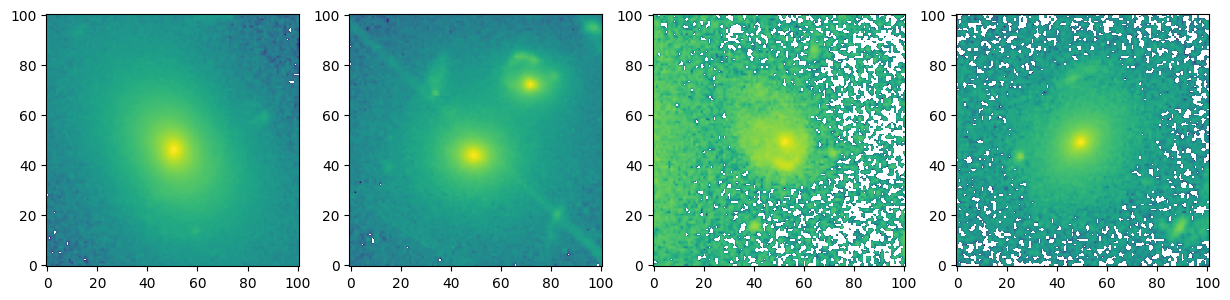

In [69]:
f, ax = plt.subplots(figsize=(15, 5), ncols=4)
for i in range(4):
    ax[i].imshow(s_im_lst[i], origin='lower', norm=LogNorm())

In [80]:
# let's do the same but using the tile from healpix 
vis_file_list2 = []
nisp_file_list2 = []
s_im_lst2 = []
for tiles in t_id_myfunc[non_zeros]:
    qq = os.listdir('/data/euclid_q1/Q1_R1/MER/%i/VIS/'%tiles)
    for f in qq:
        if 'BGSUB-MOSAIC-VIS' in f:
            vis_file_list2.append(f)
    qq2 = os.listdir('/data/euclid_q1/Q1_R1/MER/%i/NISP/'%tiles)
    for f in qq2:
        if 'BGSUB-MOSAIC-NIR' in f:   
            nisp_file_list2.append(f)
            
#            print('file is', f)
print('id, tile,     x,     y,       RA,               DEC')
for i, image_file in enumerate(vis_file_list2):
    hdu_list = fits.open('/data/euclid_q1/Q1_R1/MER/%i/VIS/%s'%(t_id_myfunc[non_zeros][i], image_file), memmap=True)
    #ima_head = fits.getheader(image_file)
    ima_head = hdu_list[0].header
    w = WCS(ima_head)
    c_obj = SkyCoord(ra=ra_bad[i]*u.deg, dec=dec_bad[i]*u.deg)
    world = w.wcs_world2pix(c_obj.ra.value, 
                        c_obj.dec.value, 1)  # 1 is origin of coordinate system
    print(i, t_id_myfunc[non_zeros][i], world[0].round(2), world[1].round(2), c_obj.ra, c_obj.dec)
    image_data = hdu_list[0].data
    i_width = 50
    xc, yc = int(world[0]), int(world[1])
    ystart, yend = yc-i_width, yc+i_width+1
    xstart, xend = xc-i_width, xc+i_width+1
    sub_ima = image_data[ystart:yend, xstart:xend]
    s_im_lst2.append(sub_ima.copy())
    hdu_list.close()

id, tile,     x,     y,       RA,               DEC
0 102158590 9445.07 18150.06 275d15m52.21323256s 65d14m14.99951365s
1 102157953 5975.54 647.17 266d55m31.78594847s 63d45m04.07655861s
2 102020062 17256.8 18586.02 61d24m23.12608463s -49d14m59.75422164s
3 102042918 770.08 18611.24 54d53m55.06696437s -28d44m57.844512s


In [52]:
ima_head['NAXIS1'], ima_head['NAXIS2'] 

(19200, 19200)

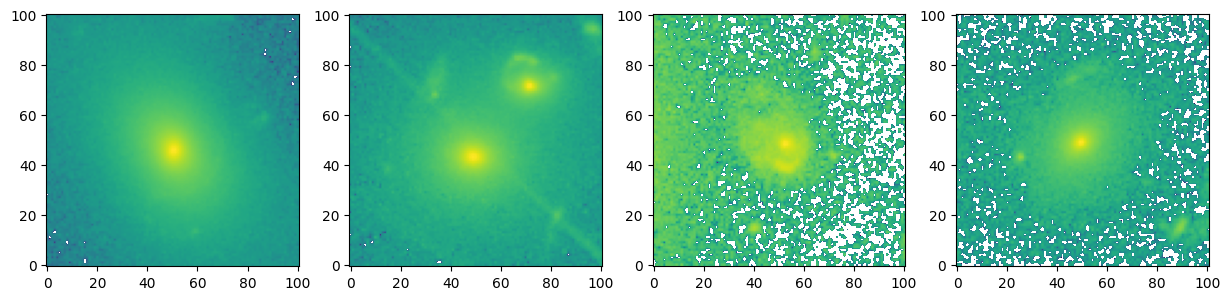

In [72]:
f, ax = plt.subplots(figsize=(15, 5), ncols=4)
for i in range(4):
    ax[i].imshow(s_im_lst2[i], origin='lower', norm=LogNorm())

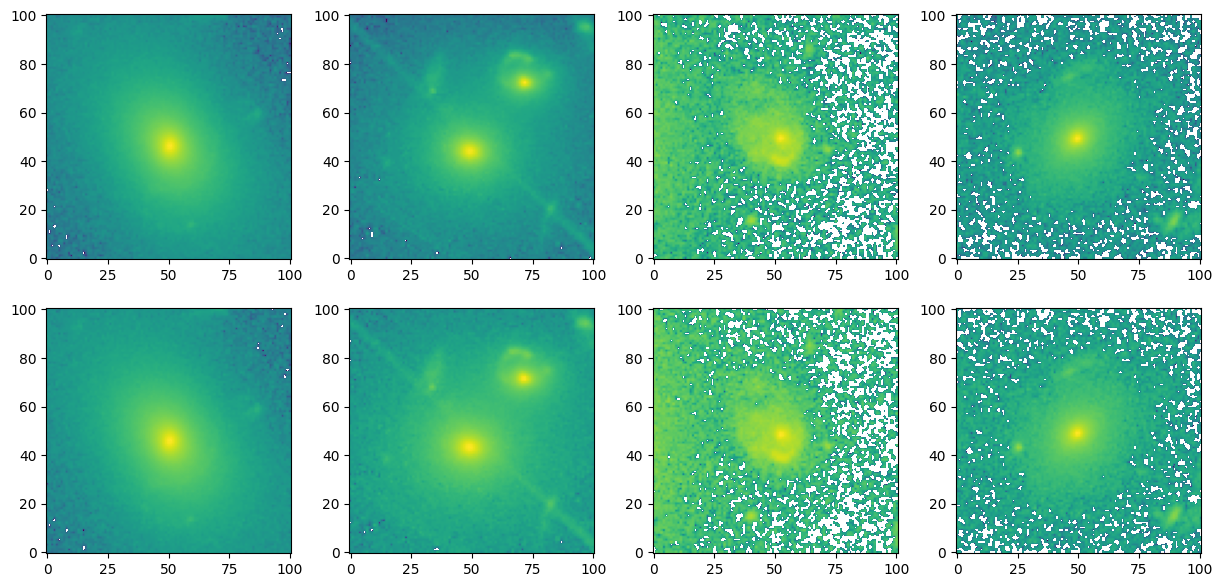

In [75]:
# COmparison from the two tiles 
f, ax = plt.subplots(figsize=(15, 7), ncols=4, nrows=2)
for i in range(4):
    ax[0, i].imshow(s_im_lst[i], origin='lower', norm=LogNorm())   # original tile 
    ax[1, i].imshow(s_im_lst2[i], origin='lower', norm=LogNorm())   # Tile derived from healpix

In [81]:
nisp_file_list2

['EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102158590-CFACC2_20241024T193454.831721Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158590-FB8D5D_20241024T192609.281309Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102158590-8A28A5_20241024T193136.889877Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102157953-CA2ED9_20241024T184137.340276Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102157953-FD0781_20241024T184836.285475Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102157953-9909B_20241024T184432.597818Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102020062-2A357E_20241018T163841.907474Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102020062-4DBD22_20241018T163920.944410Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102020062-A76E43_20241018T163503.142534Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102042918-7B283B_20241020T230457.763364Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102042918-EBE745_20241020T230220.451423Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102042918-C

In [82]:
def get_sub_lst_NIR(nisp_flist, band='J'):
    new_lst = []
    for f in nisp_flist: 
        if 'NIR-%s'%band in f: 
            new_lst.append(f)
    return new_lst

In [88]:
fn = 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102020062-4DBD22_20241018T163920.944410Z_00.00.fits'
fn[31:40]

'102020062'

In [99]:
nisp_file_lst

['EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102158896-118A0_20241024T204053.955681Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158896-6559C0_20241024T203814.910429Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102158896-BE1246_20241024T210148.314374Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102157630-DD3815_20241024T175544.459322Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102157630-151CD4_20241024T175735.825581Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102157630-968CC4_20241024T175734.462717Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102020535-6486CB_20241018T143435.506092Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102020535-E83D65_20241018T143331.980794Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102020535-B1015C_20241018T143354.308335Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-H_TILE102043552-9CA009_20241021T000441.546378Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102043552-E84327_20241021T000756.342777Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-Y_TILE102043552-D

In [106]:
def extract_sub_nir(nisp_file_list, band='J'):
    new_lst = get_sub_lst_NIR(nisp_file_list, band=band)
    s_im_lst2 = []
    for i, image_file in enumerate(new_lst):
        tile_id = image_file[31:40]  # I get the tile ID from the file name
        hdu_list = fits.open('/data/euclid_q1/Q1_R1/MER/%s/NISP/%s'%(tile_id, image_file), memmap=True)
        #ima_head = fits.getheader(image_file)
        ima_head = hdu_list[0].header
        w = WCS(ima_head)
        c_obj = SkyCoord(ra=ra_bad[i]*u.deg, dec=dec_bad[i]*u.deg)
        world = w.wcs_world2pix(c_obj.ra.value, 
                            c_obj.dec.value, 1)  # 1 is origin of coordinate system
        print(i, tile_id, world[0].round(2), world[1].round(2), c_obj.ra, c_obj.dec)
        image_data = hdu_list[0].data
        i_width = 50
        xc, yc = int(world[0]), int(world[1])
        ystart, yend = yc-i_width, yc+i_width+1
        xstart, xend = xc-i_width, xc+i_width+1
        sub_ima = image_data[ystart:yend, xstart:xend]
        s_im_lst2.append(sub_ima.copy())
        hdu_list.close()
    return s_im_lst2

In [107]:
get_sub_lst_NIR(nisp_file_lst, band='J')

['EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158896-6559C0_20241024T203814.910429Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102157630-DD3815_20241024T175544.459322Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102020535-E83D65_20241018T143331.980794Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102043552-E84327_20241021T000756.342777Z_00.00.fits']

In [109]:
get_sub_lst_NIR(nisp_file_list2, band='J')

['EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102158590-FB8D5D_20241024T192609.281309Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102157953-CA2ED9_20241024T184137.340276Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102020062-2A357E_20241018T163841.907474Z_00.00.fits',
 'EUC_MER_BGSUB-MOSAIC-NIR-J_TILE102042918-C07B66_20241020T230741.231038Z_00.00.fits']

### J-band

In [110]:
s_nir_J_ori = extract_sub_nir(nisp_file_lst, band='J') # sub images for original tile 
s_nir_J_hpix = extract_sub_nir(nisp_file_list2, band='J')

0 102158896 15601.14 456.26 275d15m52.21323256s 65d14m14.99951365s
1 102157630 3229.74 18660.77 266d55m31.78594847s 63d45m04.07655861s
2 102020535 2892.64 589.74 61d24m23.12608463s -49d14m59.75422164s
3 102043552 10579.0 621.37 54d53m55.06696437s -28d44m57.844512s
0 102158590 9445.07 18150.06 275d15m52.21323256s 65d14m14.99951365s
1 102157953 5975.54 647.17 266d55m31.78594847s 63d45m04.07655861s
2 102020062 17256.8 18586.02 61d24m23.12608463s -49d14m59.75422164s
3 102042918 770.08 18611.24 54d53m55.06696437s -28d44m57.844512s


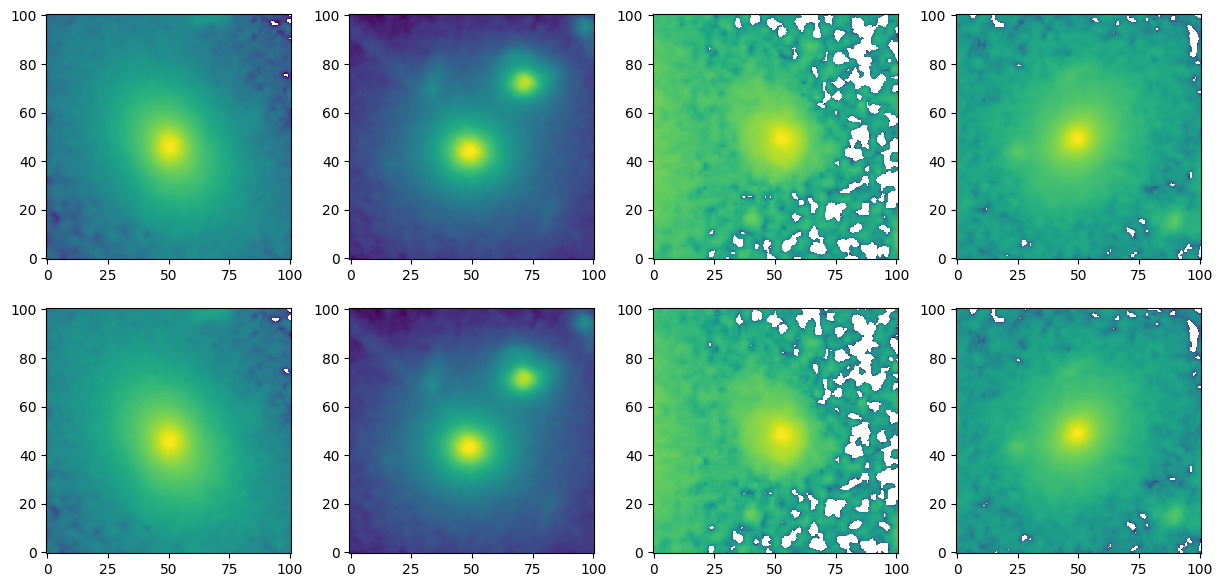

In [111]:
# Comparison of the J-band tiles
f, ax = plt.subplots(figsize=(15, 7), ncols=4, nrows=2)
for i in range(4):
    ax[0, i].imshow(s_nir_J_ori[i], origin='lower', norm=LogNorm())   # original tile 
    ax[1, i].imshow(s_nir_J_hpix[i], origin='lower', norm=LogNorm())   # Tile derived from healpix

### H-band

In [112]:
s_nir_H_ori = extract_sub_nir(nisp_file_lst, band='H') # sub images for original tile 
s_nir_H_hpix = extract_sub_nir(nisp_file_list2, band='H')

0 102158896 15601.14 456.26 275d15m52.21323256s 65d14m14.99951365s
1 102157630 3229.74 18660.77 266d55m31.78594847s 63d45m04.07655861s
2 102020535 2892.64 589.74 61d24m23.12608463s -49d14m59.75422164s
3 102043552 10579.0 621.37 54d53m55.06696437s -28d44m57.844512s
0 102158590 9445.07 18150.06 275d15m52.21323256s 65d14m14.99951365s
1 102157953 5975.54 647.17 266d55m31.78594847s 63d45m04.07655861s
2 102020062 17256.8 18586.02 61d24m23.12608463s -49d14m59.75422164s
3 102042918 770.08 18611.24 54d53m55.06696437s -28d44m57.844512s


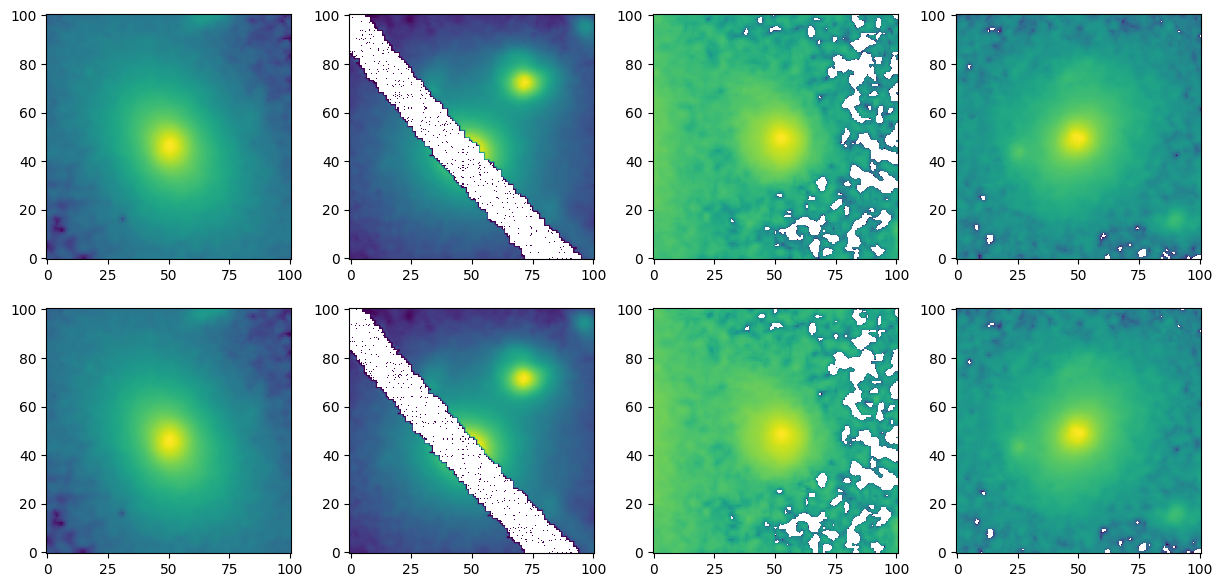

In [113]:
# Comparison of the H-band tiles
f, ax = plt.subplots(figsize=(15, 7), ncols=4, nrows=2)
for i in range(4):
    ax[0, i].imshow(s_nir_H_ori[i], origin='lower', norm=LogNorm())   # original tile 
    ax[1, i].imshow(s_nir_H_hpix[i], origin='lower', norm=LogNorm())   # Tile derived from healpix

### Y- band

In [38]:
pwd

'/media/user/my_notebooks'

In [114]:
s_nir_Y_ori = extract_sub_nir(nisp_file_lst, band='Y') # sub images for original tile 
s_nir_Y_hpix = extract_sub_nir(nisp_file_list2, band='Y')

0 102158896 15601.14 456.26 275d15m52.21323256s 65d14m14.99951365s
1 102157630 3229.74 18660.77 266d55m31.78594847s 63d45m04.07655861s
2 102020535 2892.64 589.74 61d24m23.12608463s -49d14m59.75422164s
3 102043552 10579.0 621.37 54d53m55.06696437s -28d44m57.844512s
0 102158590 9445.07 18150.06 275d15m52.21323256s 65d14m14.99951365s
1 102157953 5975.54 647.17 266d55m31.78594847s 63d45m04.07655861s
2 102020062 17256.8 18586.02 61d24m23.12608463s -49d14m59.75422164s
3 102042918 770.08 18611.24 54d53m55.06696437s -28d44m57.844512s


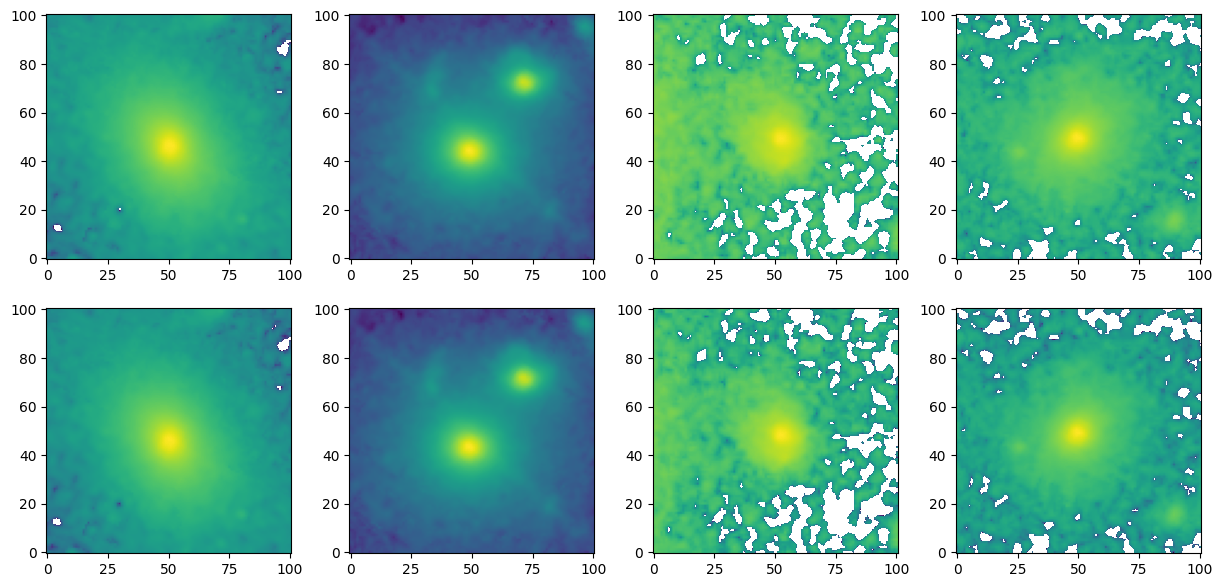

In [115]:
# Comparison of the Y-band tiles
f, ax = plt.subplots(figsize=(15, 7), ncols=4, nrows=2)
for i in range(4):
    ax[0, i].imshow(s_nir_Y_ori[i], origin='lower', norm=LogNorm())   # original tile 
    ax[1, i].imshow(s_nir_Y_hpix[i], origin='lower', norm=LogNorm())   # Tile derived from healpix

In [3]:
# Catalog 
# astropy Table
#cat_01 = Table.read('/media/user/catalog_data/Lines_Natalie_finetuned_predictions_all_q1_with_ra_dec_run3.csv', format='csv')
# df - This is what Mike tool needs
cat_01 = pd.read_csv('/media/user/catalog_data/Lines_Natalie_finetuned_predictions_all_q1_with_ra_dec_run3.csv')

In [4]:
cat_01.head(5)

,id_str,lens_pred,ra,dec
0,102022973_NEG605722088464519141_sw_arcsinh_vis...,1.000000,60.572209,-46.451914
1,102022973_NEG604677159464395173_sw_arcsinh_vis...,0.999999,60.467716,-46.439517
2,102022973_NEG603521648466724715_sw_arcsinh_vis...,1.000000,60.352165,-46.672472
3,102022973_NEG607855060462990794_sw_arcsinh_vis...,0.999996,60.785506,-46.299079
4,102022973_NEG604884976464516567_sw_arcsinh_vis...,1.000000,60.488498,-46.451657


In [5]:
# you can use this config and external target list for a minimal test on six targets within one tile...

cfg_dict = dict(
    # TODO change this path to wherever you want to save everything
    base_dir='/media/home/my_workspace/my_data/Q1_LQSO_N_Lines',
    name='external_targets_debug',

    sas_environment='IDR', # for Q1, REG for Regression, or OTF for On-The-Fly
    release_name=None, # for no specific release or e.g. 'F-006' for one release 
    release_priority=['CALBLOCK_PV-005_R2', 'CALBLOCK_PV-005_R3', 'F-003_240321', 'F-003_240612' , 'F-006', 'Q1_R1'],  # use the highest-index release first, if available
    bands=['VIS', 'NIR_J', 'NIR_H', 'NIR_Y'], # bands to use, can also have NIR_J, NIR_H. Include all bands you need for cutouts.
    auxillary_products=['MERPSF','MERRMS'],  # can also use MERBKG for background

    download_method='datalabs_path',  # to use datalabs data (Q1 only) or 'sas' for download
#    download_method='sas',  # to use datalabs data (Q1 only) or 'sas' for download
    delete_tiles=False,  # if 'sas', delete tiles after downloading them. No effect on when using 'datalabs_path'
    fits_outputs=True,  # make FITS
    jpg_outputs=['sw_mtf_vis_only', 'sw_mtf_vis_y', 'sw_arcsinh_vis_only'],  # three example processing options, see cutout_utils.py for more options. Set False for no jpg cutouts.
    jpg_quality=95,  # jpg compression strength. lower quality is much smaller but gets 'fuzzier'. See PIL.Image docs. 
    use_fits_origin_for_jpg=True,  # orient the jpg the same way up as the FITS standard
    overwrite_fits=False,  # if fits already exists, overwrite them with new cutouts
    overwrite_jpg=False,  # similarly for jpg

    # these will be filled in automatically using on base_dir
    download_dir=None,
    tile_dir=None,
    cutout_dir=None,
    fits_dir=None,
    jpg_dir=None,
    sanity_dir=None
)
cfg = OmegaConf.create(cfg_dict)  # easy to access with cfg.base_dir, etc

In [6]:
cfg.download_dir = cfg.base_dir + "/" + cfg.name
print(cfg.download_dir)
os.path.exists(os.path.dirname(cfg.download_dir))

/media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug


True

In [7]:
cat_01.columns

Index(['id_str', 'lens_pred', 'ra', 'dec'], dtype='object')

In [8]:
# Rename the columns existing DataFrame (rather than creating a copy) 
cat_01.rename(columns={'ra': 'target_ra', 'dec': 'target_dec'}, inplace=True)
cat_01['target_field_of_view'] = 18
cat_01['category'] = 'Q1_N_lines'    # I SHOULD HAVE CHANGED THE CATEGORE which defines final SUBDIR w. cutouts ... 

In [9]:
cfg.download_dir    # The filed "download_dir SHOULD exist / has to be created before running the create_folders below. 

'/media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug'

In [10]:
# Let's extract sub-catalog with the 1000 first targets ! 
# Lower lens_pred score is higher lens probability.
cat_sub = cat_01.nsmallest(1000, 'lens_pred')

In [11]:
cat_sub

,id_str,lens_pred,target_ra,target_dec,target_field_of_view,category
678918,102021017_NEG634146279486865014_sw_arcsinh_vis...,6.080505e-07,63.414628,-48.686501,18,Q1_N_lines
680966,102021017_NEG634144568486868872_sw_arcsinh_vis...,6.144933e-07,63.414457,-48.686887,18,Q1_N_lines
486121,102159773_2677079122669151496_sw_arcsinh_vis_only,6.651954e-06,267.707912,66.915150,18,Q1_N_lines
455470,102160062_2738460691675239507_sw_arcsinh_vis_only,9.546776e-06,273.846069,67.523951,18,Q1_N_lines
412557,102020064_NEG634610798496578455_sw_arcsinh_vis...,1.926391e-05,63.461080,-49.657846,18,Q1_N_lines
...,...,...,...,...,...,...
121852,102159486_2686513497663592910_sw_arcsinh_vis_only,3.790065e-01,268.651350,66.359291,18,Q1_N_lines
72811,102160610_2717023506684447045_sw_arcsinh_vis_only,3.799559e-01,271.702351,68.444705,18,Q1_N_lines
1048184,102019126_NEG591161675502826888_sw_arcsinh_vis...,3.801171e-01,59.116168,-50.282689,18,Q1_N_lines
15752,102022974_NEG608358099465405241_sw_arcsinh_vis...,3.803023e-01,60.835810,-46.540524,18,Q1_N_lines


In [12]:
pipeline.create_folders(cfg)  # fill in those missing paths

INFO:root:Saving to /media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug


{'base_dir': '/media/home/my_workspace/my_data/Q1_LQSO_N_Lines', 'name': 'external_targets_debug', 'sas_environment': 'IDR', 'release_name': None, 'release_priority': ['CALBLOCK_PV-005_R2', 'CALBLOCK_PV-005_R3', 'F-003_240321', 'F-003_240612', 'F-006', 'Q1_R1'], 'bands': ['VIS', 'NIR_J', 'NIR_H', 'NIR_Y'], 'auxillary_products': ['MERPSF', 'MERRMS'], 'download_method': 'datalabs_path', 'delete_tiles': False, 'fits_outputs': True, 'jpg_outputs': ['sw_mtf_vis_only', 'sw_mtf_vis_y', 'sw_arcsinh_vis_only'], 'jpg_quality': 95, 'use_fits_origin_for_jpg': True, 'overwrite_fits': False, 'overwrite_jpg': False, 'download_dir': '/media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug', 'tile_dir': '/media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug/tiles', 'cutout_dir': '/media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug/cutouts', 'fits_dir': '/media/home/my_workspace/my_data/Q1_LQSO_N_Lines/external_targets_debug/cutouts/fits', 'jpg_dir':

In [13]:
cfg.jpg_outputs

['sw_mtf_vis_only', 'sw_mtf_vis_y', 'sw_arcsinh_vis_only']

In [14]:
# Check duplicates
assert not any(cat_sub['id_str'].duplicated())

In [15]:
# # type in your COSMOS credentials
# from astroquery.esa.euclid.core import EuclidClass
# Euclid = EuclidClass(environment=cfg.sas_environment)
# Euclid.login()

# the code below is a shorthand version for the above
# it adds Euclid to Python's globals, which saves passing it around all the time
from bulk_euclid.utils import pipeline_utils
pipeline_utils.login(cfg)

AttributeError: module 'bulk_euclid.utils.pipeline_utils' has no attribute 'login'